In [1]:
%pip install "numpy<2.0" "opencv-python==4.8.0.74" cellpose==3.0.10 -q
%pip install pyocclient -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 12.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.0/205.0 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 40.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 69.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 10.8 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 8.1 MB/s eta 0:00:00:00:0100:01m
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you 

In [8]:
!pip install "cellpose<4.0" --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00


In [3]:
import owncloud, getpass

# Config
url, user = 'https://cloud.minesparis.psl.eu', 'gabriel.gautier'
oc_session = owncloud.Client(url)
oc_session.login(user, getpass.getpass(f"PW {user}: "))
oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

import tool
oc = tool.Owncloud(oc_session)

print("Tool chargé et prêt.")

Tool chargé et prêt.


In [4]:
# Usage direct pour tes noyaux propres
oc.download_path('./data/2-Annotations/02-Annotations_Clean', '/travail/Mines/DIMA/Segmentation/data/02-Annotations_Clean')

✅ Dossier 02-Annotations_Clean envoyé vers /travail/Mines/DIMA/Segmentation/data/02-Annotations_Clean.zip


In [10]:
!nvcc --version
!nvidia-smi

/bin/bash: line 1: nvcc: command not found
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
oc.upload_data()

In [2]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2

from cellpose import core, utils, io, models, metrics, train, dynamics
from glob import glob

import importlib

In [3]:
oc.upload_scripts()
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [4]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

>>> GPU activated? NO


In [4]:

io.logger_setup()

model = models.CellposeModel(gpu=True, model_type="cyto3")

path = '001'
img = visualizer.load_data(path, mode='Image')

masks, flows, styles = model.eval(img, 
                                  diameter=65, 
                                  channels=[0,0],
                                  resample=True)


output_dir = './data/processed/cellpose/annotation'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks)

print(f"Masque sauvegardé : {save_path}")

Masque sauvegardé : ./data/processed/cellpose/annotation/001_Cell_pred.bmp


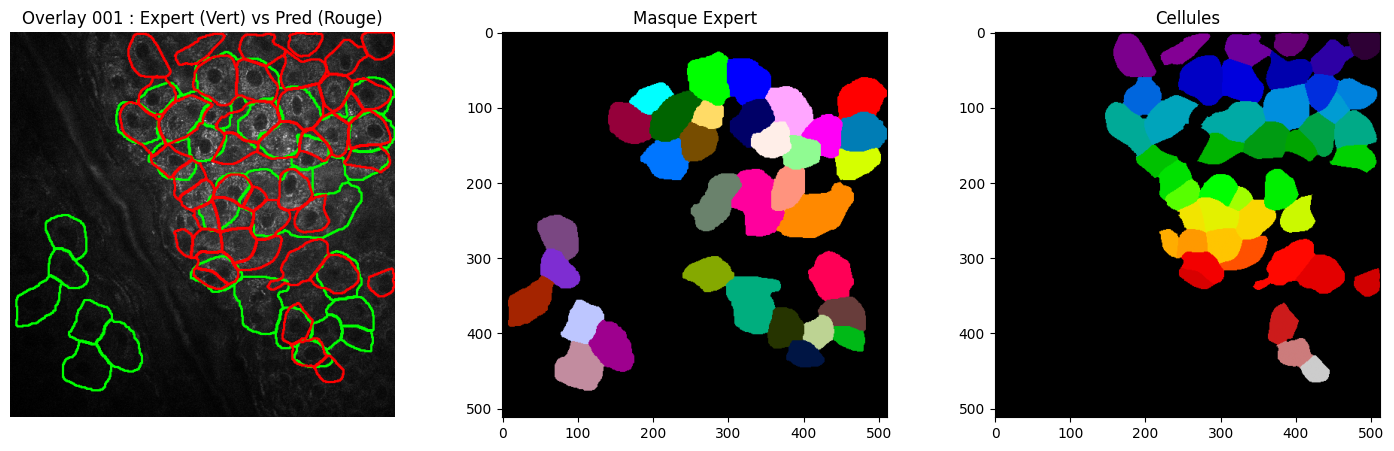

[Cellpose] F1: 0.100 | TP: 3 | FN: 12


{'f1': 0.10000000149011612,
 'ap': 0.05263157933950424,
 'tp': 3,
 'fp': 42,
 'fn': 12}

In [6]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data = masks, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose", true_mask, masks)


100%|██████████| 2/2 [00:00<00:00, 448.64it/s]


Modèle sauvegardé : models/cyto3_pro


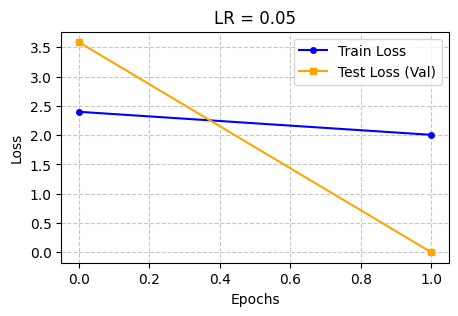

<Axes: title={'center': 'LR = 0.05'}, xlabel='Epochs', ylabel='Loss'>

In [5]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

ids_train = ['002', '003', '004','005']
ids_val   = ['011', '012']

X_train = [visualizer.load_data(id, 'Image') for id in ids_train]
Y_train = [visualizer.load_data(id, 'Cell')[:,:,0] for id in ids_train]
X_val   = [visualizer.load_data(id, 'Image') for id in ids_val]
Y_val   = [visualizer.load_data(id, 'Cell')[:,:,0] for id in ids_val]

io.logger_setup()
model_finetune = models.CellposeModel(model_type='cyto3', gpu=False)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    channels=[0,0],
    n_epochs=2,          
    learning_rate=0.05,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cyto3_pro'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


In [6]:
io.logger_setup()

model = models.CellposeModel(gpu=False, pretrained_model= str(model_path))

img_id = '001'
img = visualizer.load_data(img_id, mode='Image')

masks, flows, styles = model.eval(img, 
                                  diameter=None, 
                                  channels=[0,0],
                                  resample=True)

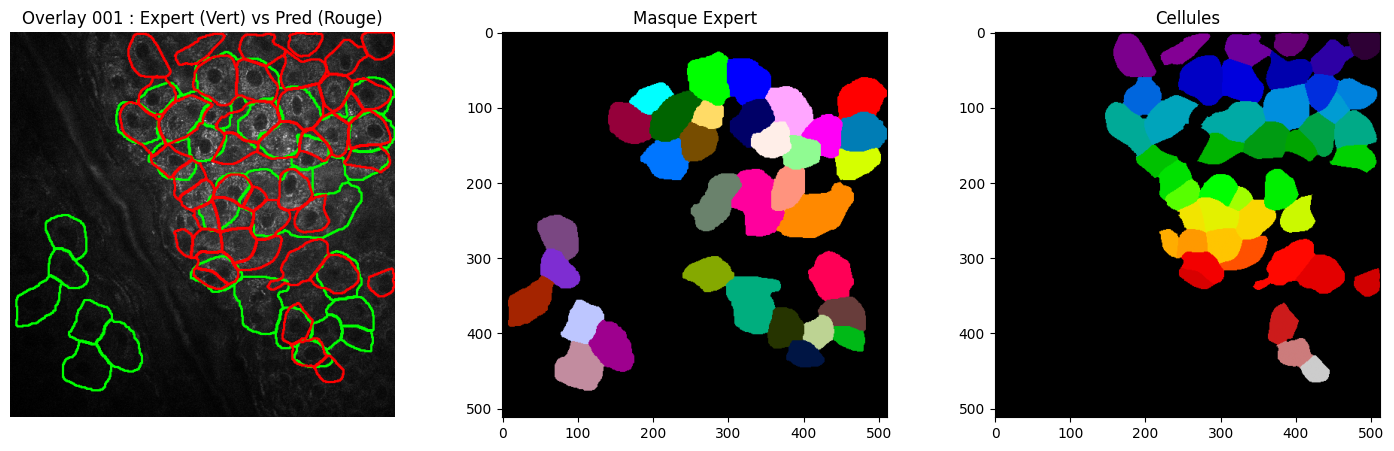

[Cellpose] F1: 0.100 | TP: 3 | FN: 12


{'f1': 0.10000000149011612,
 'ap': 0.05263157933950424,
 'tp': 3,
 'fp': 42,
 'fn': 12}

In [7]:
true_mask = visualizer.load_data("001", mode='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data = masks, mode = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", mode='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()
ev.report("Cellpose", true_mask, masks)


Split : Train(14) | Val(2) | Test(4)

--- Test LR = 0.1 ---


100%|██████████| 2/2 [00:00<00:00, 451.10it/s]


-> Val Loss : 0.0000


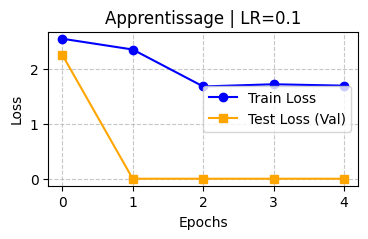


--- Test LR = 0.05 ---


100%|██████████| 2/2 [00:00<00:00, 429.04it/s]


-> Val Loss : 0.0000


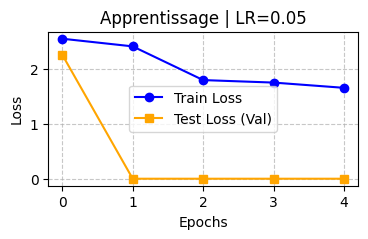


--- Test LR = 0.01 ---


100%|██████████| 2/2 [00:00<00:00, 312.56it/s]


-> Val Loss : 0.0000


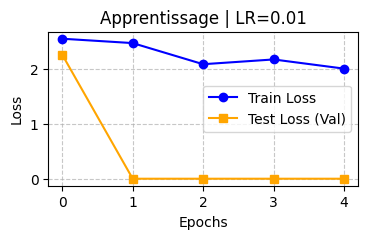


=== GAGNANT : LR=0.1 ===
Chemin du modèle prêt pour le test : models/cyto3_lr_0.1


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io

# 1. Split 70-10-20 reproductible
# Remplace cette liste par un scan de ton dossier (ex: all_ids = [p.stem for p in visualizer.img_dir.glob("*.tif")])
all_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020'] 

random.seed(42)
random.shuffle(all_ids)

n = len(all_ids)
ids_train = all_ids[:int(0.7 * n)]
ids_val   = all_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = all_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

# Fonction utilitaire de chargement
def load_set(ids):
    X = [visualizer.load_data(i, 'Image') for i in ids]
    Y = [visualizer.load_data(i, 'Cell')[:,:,0] for i in ids]
    return X, Y

X_train, Y_train = load_set(ids_train)
X_val, Y_val     = load_set(ids_val)
X_test, Y_test   = load_set(ids_test)

# 2. Boucle minimaliste sur les LR
io.logger_setup()
learning_rates = [0.1, 0.05, 0.01] # 0.1 est le défaut classique, on teste juste autour

fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

for i, lr in enumerate(learning_rates):
    print(f"\n--- Test LR = {lr} ---")
    
    # On recharge un modèle neuf à chaque itération pour ne pas cumuler l'apprentissage
    model = models.CellposeModel(model_type='cyto3', gpu=False)
    
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        channels=[0,0],
        n_epochs=5,          # À passer à 100-200 avec le GPU
        learning_rate=lr,
        weight_decay=0.0001, # Valeur standard robuste
        save_path='.',
        model_name=f'cyto3_lr_{lr}'
    )
    
    final_val_loss = v_loss[-1]
    print(f"-> Val Loss : {final_val_loss:.4f}")
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr}", ax=axes[i], show=False)
    

plt.show()
